## **Load the Required Libraries**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, classification_report

## **1.1 : Data Importation and Preparation**

#### **Step 1: Loading the Dataset**

In [48]:
web_analytics_data = pd.read_csv("Web-Analytics.csv")
churn_detection_data = pd.read_csv("churn_detection_data.csv")

In [49]:
web_analytics_preview = web_analytics_data.head(10)
web_analytics_preview

,Date,Traffic_Source,Traffic_Medium,Device_Category,Landing_Page,Users,New_Users,Sessions,Pageviews,Bounce_Rate_Pct,...,Pages_Per_Session,Exit_Rate_Pct,Conversion_Rate_Pct,Transactions,Quantity_Sold,Revenue_KES,Cart_Abandonment_Rate_Pct,Marketing_Cost_KES,ROAS,Customer_Journey_Stage
0,1/3/2024,Direct,No Media,Mobile,Product_Page,516,396,552,1524,51.99,...,2.76,56.20,0.96,5,5,12368.85,85.49,0.00,NaN,Retention
1,9/19/2024,Direct,No Media,Tablet,Category_Page,600,444,723,2523,39.79,...,3.49,43.51,3.03,22,44,41251.73,75.45,0.00,NaN,Consideration
2,10/21/2022,Twitter,Organic,Mobile,Homepage,342,234,360,796,55.96,...,2.21,60.02,0.78,3,6,10037.63,82.74,0.00,NaN,Awareness
3,2/5/2025,Google,Organic,Tablet,Product_Page,359,311,495,1124,58.02,...,2.27,61.42,3.69,18,18,68704.44,76.66,0.00,NaN,Consideration
4,6/13/2022,Direct,No Media,Mobile,Category_Page,332,289,440,1016,57.73,...,2.31,51.21,0.98,4,4,11359.82,79.57,0.00,NaN,Consideration
5,4/14/2025,Email,Newsletter,Mobile,Homepage,562,187,710,2549,47.97,...,3.59,50.78,4.30,31,93,130391.09,73.39,0.00,NaN,Consideration
6,1/24/2023,Linkedin,Paid,Desktop,Promo_Page,599,250,636,3294,15.00,...,5.18,20.00,7.37,47,47,251378.45,61.36,28885.37,8.70,Decision
7,10/14/2022,Instagram,Paid,Desktop,Category_Page,184,78,220,717,42.10,...,3.26,39.29,5.52,12,12,36236.49,67.26,5034.82,7.20,Consideration
8,3/22/2024,Instagram,Paid,Mobile,Blog,124,33,154,273,64.56,...,1.77,56.86,0.37,1,1,2740.09,87.34,3263.33,0.84,Awareness
9,11/10/2022,Facebook,Paid,Desktop,Blog,522,115,689,1447,58.81,...,2.10,51.67,4.00,28,28,148393.74,74.00,18377.55,8.07,Awareness


In [50]:
churn_detection_preview = churn_detection_data.head(10)
churn_detection_preview

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Account_Tenure_Months,Account_Type,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
0,CUST2463,32,Male,Divorced,Primary,Employed,13,Current,2,57001,19,6,10,0,0.97,0,1,0,0,1
1,CUST2511,45,Male,Single,University,Employed,88,Current,1,24533,14,5,9,0,0.89,2,1,0,0,0
2,CUST2227,29,Female,Single,Primary,Employed,151,Savings,3,212133,16,11,7,1,0.71,2,1,0,0,0
3,CUST0526,49,Female,Single,Secondary,Employed,118,Savings,2,94045,22,12,8,0,0.89,0,1,0,0,0
4,CUST0195,33,Female,Single,Primary,Employed,108,Savings,1,137693,15,7,8,0,0.64,1,0,0,0,0
5,CUST2986,33,Female,Married,Secondary,Self-employed,69,Savings,3,63153,15,9,11,0,0.78,2,0,0,0,1
6,CUST1842,41,Male,Married,University,Employed,167,Current,2,378881,11,7,14,1,0.63,1,1,0,0,0
7,CUST1142,41,Female,Single,Primary,Self-employed,68,Current,1,43330,10,10,7,0,0.95,2,1,0,0,0
8,CUST1253,49,Female,Married,Secondary,Self-employed,78,Current,4,307651,18,7,9,1,0.87,2,1,0,0,1
9,CUST1268,40,Female,Single,Primary,Employed,143,Savings,2,105577,16,9,8,0,0.66,0,1,0,0,0


#### **Step 2: Displaying the Dimensions**

In [51]:
dimensions_summary = {"Churn Detection shape": churn_detection_data.shape}

dimensions_summary

{'Churn Detection shape': (10000, 20)}

In [52]:
dimensions_summary = {"Web Analytics shape": web_analytics_data.shape}

dimensions_summary

{'Web Analytics shape': (25000, 21)}

#### **Displaying the Data Types**

In [53]:
dtypes_summary = {"Churn Detection dtypes": churn_detection_data.dtypes}

dtypes_summary

{'Churn Detection dtypes': Customer_ID                   object
 Age                            int64
 Gender                        object
 Marital_Status                object
 Education_Level               object
 Employment_Status             object
 Account_Tenure_Months          int64
 Account_Type                  object
 Number_of_Products             int64
 Average_Balance                int64
 Monthly_Transactions           int64
 Online_Banking_Usage           int64
 Mobile_Banking_Usage           int64
 Number_of_Complaints           int64
 Complaint_Resolution_Rate    float64
 Customer_Support_Calls         int64
 Email_Opt_In                   int64
 Credit_Card_Holder             int64
 Loan_Account_Holder            int64
 Churn                          int64
 dtype: object}

In [54]:
dtypes_summary = {"Web Analytics dtypes": web_analytics_data.dtypes}

dtypes_summary

{'Web Analytics dtypes': Date                          object
 Traffic_Source                object
 Traffic_Medium                object
 Device_Category               object
 Landing_Page                  object
 Users                          int64
 New_Users                      int64
 Sessions                       int64
 Pageviews                      int64
 Bounce_Rate_Pct              float64
 Avg_Session_Duration_Sec       int64
 Pages_Per_Session            float64
 Exit_Rate_Pct                float64
 Conversion_Rate_Pct          float64
 Transactions                   int64
 Quantity_Sold                  int64
 Revenue_KES                  float64
 Cart_Abandonment_Rate_Pct    float64
 Marketing_Cost_KES           float64
 ROAS                         float64
 Customer_Journey_Stage        object
 dtype: object}

#### **Summary Statistics**

In [55]:
web_analytics_summary = web_analytics_data.describe(include="all")
web_analytics_summary

,Date,Traffic_Source,Traffic_Medium,Device_Category,Landing_Page,Users,New_Users,Sessions,Pageviews,Bounce_Rate_Pct,...,Pages_Per_Session,Exit_Rate_Pct,Conversion_Rate_Pct,Transactions,Quantity_Sold,Revenue_KES,Cart_Abandonment_Rate_Pct,Marketing_Cost_KES,ROAS,Customer_Journey_Stage
count,25000,25000,25000,25000,25000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,12850.000000,25000
unique,1461,10,5,3,5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,9/7/2025,Google,Paid,Mobile,Product_Page,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Consideration
freq,30,6182,11585,15384,7525,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12443
mean,NaN,NaN,NaN,NaN,NaN,325.559800,173.01848,406.643800,1217.536560,50.600586,...,2.993544,49.391481,3.371492,13.715240,23.383960,53993.224405,76.182113,5176.442574,6.725774,NaN
std,NaN,NaN,NaN,NaN,NaN,159.330886,123.90785,203.241089,720.215959,14.393734,...,0.844363,14.348942,2.096500,11.755635,25.984662,58051.356291,8.118720,7484.330697,7.862291,NaN
min,NaN,NaN,NaN,NaN,NaN,50.000000,8.00000,53.000000,63.000000,15.000000,...,1.100000,20.000000,0.200000,0.000000,0.000000,0.000000,45.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,187.000000,75.00000,232.000000,629.000000,41.020000,...,2.400000,39.510000,1.720000,5.000000,7.000000,14690.620000,71.020000,0.000000,1.882500,NaN
50%,NaN,NaN,NaN,NaN,NaN,327.000000,137.00000,406.000000,1119.000000,50.940000,...,2.970000,49.390000,2.960000,10.000000,15.000000,33582.985000,77.070000,1314.585000,4.170000,NaN
75%,NaN,NaN,NaN,NaN,NaN,463.000000,248.00000,574.250000,1682.000000,61.080000,...,3.570000,59.300000,4.780000,19.000000,30.000000,73732.932500,82.190000,8359.612500,8.550000,NaN


In [56]:
churn_detection_summary = churn_detection_data.describe(include="all")
churn_detection_summary

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Account_Tenure_Months,Account_Type,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
count,10000,10000.00000,10000,10000,8974,10000,10000.000000,10000,10000.000000,1.000000e+04,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
unique,2899,NaN,2,3,3,3,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST1448,NaN,Female,Married,Secondary,Employed,NaN,Savings,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,13,NaN,5035,5036,3995,6055,NaN,5932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,35.15840,NaN,NaN,NaN,NaN,90.817100,NaN,2.005800,1.501083e+05,15.053100,8.00500,10.027600,0.193300,0.747475,1.01120,0.691600,0.298300,0.206900,0.273200
std,NaN,9.62961,NaN,NaN,NaN,NaN,51.771835,NaN,1.005021,1.513211e+05,3.870294,2.85198,3.175791,0.437898,0.144261,1.00746,0.461856,0.457535,0.405103,0.445625
min,NaN,18.00000,NaN,NaN,NaN,NaN,1.000000,NaN,1.000000,5.000000e+02,3.000000,0.00000,0.000000,0.000000,0.500000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,NaN,28.00000,NaN,NaN,NaN,NaN,46.000000,NaN,1.000000,4.422200e+04,12.000000,6.00000,8.000000,0.000000,0.620000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,NaN,35.00000,NaN,NaN,NaN,NaN,91.000000,NaN,2.000000,1.036505e+05,15.000000,8.00000,10.000000,0.000000,0.750000,1.00000,1.000000,0.000000,0.000000,0.000000
75%,NaN,42.00000,NaN,NaN,NaN,NaN,136.000000,NaN,3.000000,2.065610e+05,18.000000,10.00000,12.000000,0.000000,0.870000,2.00000,1.000000,1.000000,0.000000,1.000000


#### **Step 3: Identifying Missing Values**

In [57]:
missing_values_summary = {"Web Analytics missing": web_analytics_data.isnull().sum()}

missing_values_summary

{'Web Analytics missing': Date                             0
 Traffic_Source                   0
 Traffic_Medium                   0
 Device_Category                  0
 Landing_Page                     0
 Users                            0
 New_Users                        0
 Sessions                         0
 Pageviews                        0
 Bounce_Rate_Pct                  0
 Avg_Session_Duration_Sec         0
 Pages_Per_Session                0
 Exit_Rate_Pct                    0
 Conversion_Rate_Pct              0
 Transactions                     0
 Quantity_Sold                    0
 Revenue_KES                      0
 Cart_Abandonment_Rate_Pct        0
 Marketing_Cost_KES               0
 ROAS                         12150
 Customer_Journey_Stage           0
 dtype: int64}

In [58]:
missing_values_summary = {"Churn Detection missing": churn_detection_data.isnull().sum()}

missing_values_summary

{'Churn Detection missing': Customer_ID                     0
 Age                             0
 Gender                          0
 Marital_Status                  0
 Education_Level              1026
 Employment_Status               0
 Account_Tenure_Months           0
 Account_Type                    0
 Number_of_Products              0
 Average_Balance                 0
 Monthly_Transactions            0
 Online_Banking_Usage            0
 Mobile_Banking_Usage            0
 Number_of_Complaints            0
 Complaint_Resolution_Rate       0
 Customer_Support_Calls          0
 Email_Opt_In                    0
 Credit_Card_Holder              0
 Loan_Account_Holder             0
 Churn                           0
 dtype: int64}

#### **Identifying Duplicates**

In [59]:
duplicates_summary = {"Churn Detection duplicates": churn_detection_data.duplicated().sum()}

duplicates_summary

{'Churn Detection duplicates': np.int64(0)}

In [60]:
duplicates_summary = {"Web Analytics duplicates": web_analytics_data.duplicated().sum()}

duplicates_summary

{'Web Analytics duplicates': np.int64(0)}

#### **Structural Anomalies**

In [61]:
web_cat_uniques = {
    col: {
        "Unique Count": web_analytics_data[col].nunique(),
        "Unique Values": list(web_analytics_data[col].unique())}
    for col in web_analytics_data.select_dtypes(include="object").columns}

web_cat_uniques_df = pd.DataFrame(web_cat_uniques).T
web_cat_uniques_df


,Unique Count,Unique Values
Date,1461,"[1/3/2024, 9/19/2024, 10/21/2022, 2/5/2025, 6/..."
Traffic_Source,10,"[Direct, Twitter, Google, Email, Linkedin, Ins..."
Traffic_Medium,5,"[No Media, Organic, Newsletter, Paid, Cpc]"
Device_Category,3,"[Mobile, Tablet, Desktop]"
Landing_Page,5,"[Product_Page, Category_Page, Homepage, Promo_..."
Customer_Journey_Stage,4,"[Retention, Consideration, Awareness, Decision]"


In [62]:
churn_cat_uniques = {
    col: {
        "Unique Count": churn_detection_data[col].nunique(),
        "Unique Values": list(churn_detection_data[col].unique())}
    for col in churn_detection_data.select_dtypes(include="object").columns}

churn_cat_uniques_df = pd.DataFrame(churn_cat_uniques).T
churn_cat_uniques_df


,Unique Count,Unique Values
Customer_ID,2899,"[CUST2463, CUST2511, CUST2227, CUST0526, CUST0..."
Gender,2,"[Male, Female]"
Marital_Status,3,"[Divorced, Single, Married]"
Education_Level,3,"[Primary, University, Secondary, nan]"
Employment_Status,3,"[Employed, Self-employed, Unemployed]"
Account_Type,3,"[Current, Savings, Fixed Deposit]"


#### **Step 4: Cleaning Strategies**

##### **Step 4a: Handling Missing Values**

In [63]:
web_analytics_clean = web_analytics_data.dropna()

web_analytics_filled = web_analytics_data.fillna({col: "Unknown" 
                                                  for col in web_analytics_data.select_dtypes(include="object").columns}).fillna(0)

web_analytics_clean.head()
web_analytics_filled.head()


,Date,Traffic_Source,Traffic_Medium,Device_Category,Landing_Page,Users,New_Users,Sessions,Pageviews,Bounce_Rate_Pct,...,Pages_Per_Session,Exit_Rate_Pct,Conversion_Rate_Pct,Transactions,Quantity_Sold,Revenue_KES,Cart_Abandonment_Rate_Pct,Marketing_Cost_KES,ROAS,Customer_Journey_Stage
0,1/3/2024,Direct,No Media,Mobile,Product_Page,516,396,552,1524,51.99,...,2.76,56.20,0.96,5,5,12368.85,85.49,0.0,0.0,Retention
1,9/19/2024,Direct,No Media,Tablet,Category_Page,600,444,723,2523,39.79,...,3.49,43.51,3.03,22,44,41251.73,75.45,0.0,0.0,Consideration
2,10/21/2022,Twitter,Organic,Mobile,Homepage,342,234,360,796,55.96,...,2.21,60.02,0.78,3,6,10037.63,82.74,0.0,0.0,Awareness
3,2/5/2025,Google,Organic,Tablet,Product_Page,359,311,495,1124,58.02,...,2.27,61.42,3.69,18,18,68704.44,76.66,0.0,0.0,Consideration
4,6/13/2022,Direct,No Media,Mobile,Category_Page,332,289,440,1016,57.73,...,2.31,51.21,0.98,4,4,11359.82,79.57,0.0,0.0,Consideration


In [64]:
churn_detection_clean = churn_detection_data.dropna()

churn_detection_filled = churn_detection_data.fillna({col: "Unknown" 
                                                      for col in churn_detection_data.select_dtypes(include="object").columns}).fillna(0)

churn_detection_clean.head()
churn_detection_filled.head()

,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Account_Tenure_Months,Account_Type,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
0,CUST2463,32,Male,Divorced,Primary,Employed,13,Current,2,57001,19,6,10,0,0.97,0,1,0,0,1
1,CUST2511,45,Male,Single,University,Employed,88,Current,1,24533,14,5,9,0,0.89,2,1,0,0,0
2,CUST2227,29,Female,Single,Primary,Employed,151,Savings,3,212133,16,11,7,1,0.71,2,1,0,0,0
3,CUST0526,49,Female,Single,Secondary,Employed,118,Savings,2,94045,22,12,8,0,0.89,0,1,0,0,0
4,CUST0195,33,Female,Single,Primary,Employed,108,Savings,1,137693,15,7,8,0,0.64,1,0,0,0,0


##### **Step 4b: Handling Duplicates**

In [65]:
web_analytics_no_dupes = web_analytics_data.drop_duplicates()

print("Duplicates remaining:", web_analytics_no_dupes.duplicated().sum())
web_analytics_no_dupes.head()


Duplicates remaining: 0


,Date,Traffic_Source,Traffic_Medium,Device_Category,Landing_Page,Users,New_Users,Sessions,Pageviews,Bounce_Rate_Pct,...,Pages_Per_Session,Exit_Rate_Pct,Conversion_Rate_Pct,Transactions,Quantity_Sold,Revenue_KES,Cart_Abandonment_Rate_Pct,Marketing_Cost_KES,ROAS,Customer_Journey_Stage
0,1/3/2024,Direct,No Media,Mobile,Product_Page,516,396,552,1524,51.99,...,2.76,56.20,0.96,5,5,12368.85,85.49,0.0,NaN,Retention
1,9/19/2024,Direct,No Media,Tablet,Category_Page,600,444,723,2523,39.79,...,3.49,43.51,3.03,22,44,41251.73,75.45,0.0,NaN,Consideration
2,10/21/2022,Twitter,Organic,Mobile,Homepage,342,234,360,796,55.96,...,2.21,60.02,0.78,3,6,10037.63,82.74,0.0,NaN,Awareness
3,2/5/2025,Google,Organic,Tablet,Product_Page,359,311,495,1124,58.02,...,2.27,61.42,3.69,18,18,68704.44,76.66,0.0,NaN,Consideration
4,6/13/2022,Direct,No Media,Mobile,Category_Page,332,289,440,1016,57.73,...,2.31,51.21,0.98,4,4,11359.82,79.57,0.0,NaN,Consideration


In [66]:
churn_detection_no_dupes = churn_detection_data.drop_duplicates()

print("Duplicates remaining:", churn_detection_no_dupes.duplicated().sum())
churn_detection_no_dupes.head()


Duplicates remaining: 0


,Customer_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Account_Tenure_Months,Account_Type,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
0,CUST2463,32,Male,Divorced,Primary,Employed,13,Current,2,57001,19,6,10,0,0.97,0,1,0,0,1
1,CUST2511,45,Male,Single,University,Employed,88,Current,1,24533,14,5,9,0,0.89,2,1,0,0,0
2,CUST2227,29,Female,Single,Primary,Employed,151,Savings,3,212133,16,11,7,1,0.71,2,1,0,0,0
3,CUST0526,49,Female,Single,Secondary,Employed,118,Savings,2,94045,22,12,8,0,0.89,0,1,0,0,0
4,CUST0195,33,Female,Single,Primary,Employed,108,Savings,1,137693,15,7,8,0,0.64,1,0,0,0,0


##### **Step 4c: Cleaning Categorical Anomalies**

In [67]:
for col in web_analytics_data.select_dtypes(include="object").columns:
    web_analytics_data[col] = web_analytics_data[col].str.strip().str.title()

web_analytics_data["Traffic_Medium"] = web_analytics_data["Traffic_Medium"].replace({
    "Cpc": "CPC",
    "No Media": "No Media"})

web_analytics_data[["Traffic_Source", "Traffic_Medium", "Device_Category", 
                    "Landing_Page", "Customer_Journey_Stage"]].head(10)


,Traffic_Source,Traffic_Medium,Device_Category,Landing_Page,Customer_Journey_Stage
0,Direct,No Media,Mobile,Product_Page,Retention
1,Direct,No Media,Tablet,Category_Page,Consideration
2,Twitter,Organic,Mobile,Homepage,Awareness
3,Google,Organic,Tablet,Product_Page,Consideration
4,Direct,No Media,Mobile,Category_Page,Consideration
5,Email,Newsletter,Mobile,Homepage,Consideration
6,Linkedin,Paid,Desktop,Promo_Page,Decision
7,Instagram,Paid,Desktop,Category_Page,Consideration
8,Instagram,Paid,Mobile,Blog,Awareness
9,Facebook,Paid,Desktop,Blog,Awareness


In [68]:
for col in churn_detection_data.select_dtypes(include="object").columns:
    churn_detection_data[col] = churn_detection_data[col].str.strip().str.title()

churn_detection_data.select_dtypes(include="object").head(10)


,Customer_ID,Gender,Marital_Status,Education_Level,Employment_Status,Account_Type
0,Cust2463,Male,Divorced,Primary,Employed,Current
1,Cust2511,Male,Single,University,Employed,Current
2,Cust2227,Female,Single,Primary,Employed,Savings
3,Cust0526,Female,Single,Secondary,Employed,Savings
4,Cust0195,Female,Single,Primary,Employed,Savings
5,Cust2986,Female,Married,Secondary,Self-Employed,Savings
6,Cust1842,Male,Married,University,Employed,Current
7,Cust1142,Female,Single,Primary,Self-Employed,Current
8,Cust1253,Female,Married,Secondary,Self-Employed,Current
9,Cust1268,Female,Single,Primary,Employed,Savings


## **1.2 Data Wrangling and Manipulation**

### **Step 1: Standardize Column Names & Vonvert Date Columns**

In [69]:
# Standardizing column names: lowercase, replace spaces with underscores
web_analytics_data.columns = (
    web_analytics_data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_"))

# Converting date column to datetime
web_analytics_data["date"] = pd.to_datetime(web_analytics_data["date"], errors="coerce")


web_analytics_data.head()


,date,traffic_source,traffic_medium,device_category,landing_page,users,new_users,sessions,pageviews,bounce_rate_pct,...,pages_per_session,exit_rate_pct,conversion_rate_pct,transactions,quantity_sold,revenue_kes,cart_abandonment_rate_pct,marketing_cost_kes,roas,customer_journey_stage
0,2024-01-03,Direct,No Media,Mobile,Product_Page,516,396,552,1524,51.99,...,2.76,56.20,0.96,5,5,12368.85,85.49,0.0,NaN,Retention
1,2024-09-19,Direct,No Media,Tablet,Category_Page,600,444,723,2523,39.79,...,3.49,43.51,3.03,22,44,41251.73,75.45,0.0,NaN,Consideration
2,2022-10-21,Twitter,Organic,Mobile,Homepage,342,234,360,796,55.96,...,2.21,60.02,0.78,3,6,10037.63,82.74,0.0,NaN,Awareness
3,2025-02-05,Google,Organic,Tablet,Product_Page,359,311,495,1124,58.02,...,2.27,61.42,3.69,18,18,68704.44,76.66,0.0,NaN,Consideration
4,2022-06-13,Direct,No Media,Mobile,Category_Page,332,289,440,1016,57.73,...,2.31,51.21,0.98,4,4,11359.82,79.57,0.0,NaN,Consideration


In [70]:
# Standardizing column names: lowercase, replace spaces with underscores
churn_detection_data.columns = (
    churn_detection_data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_"))

churn_detection_data.head()


,customer_id,age,gender,marital_status,education_level,employment_status,account_tenure_months,account_type,number_of_products,average_balance,monthly_transactions,online_banking_usage,mobile_banking_usage,number_of_complaints,complaint_resolution_rate,customer_support_calls,email_opt_in,credit_card_holder,loan_account_holder,churn
0,Cust2463,32,Male,Divorced,Primary,Employed,13,Current,2,57001,19,6,10,0,0.97,0,1,0,0,1
1,Cust2511,45,Male,Single,University,Employed,88,Current,1,24533,14,5,9,0,0.89,2,1,0,0,0
2,Cust2227,29,Female,Single,Primary,Employed,151,Savings,3,212133,16,11,7,1,0.71,2,1,0,0,0
3,Cust0526,49,Female,Single,Secondary,Employed,118,Savings,2,94045,22,12,8,0,0.89,0,1,0,0,0
4,Cust0195,33,Female,Single,Primary,Employed,108,Savings,1,137693,15,7,8,0,0.64,1,0,0,0,0


In [71]:
# Converting date columns to datetime
if "signup_date" in churn_detection_data.columns:
    churn_detection_data["signup_date"] = pd.to_datetime(
        churn_detection_data["signup_date"], errors="coerce")

if "last_interaction_date" in churn_detection_data.columns:
    churn_detection_data["last_interaction_date"] = pd.to_datetime(
        churn_detection_data["last_interaction_date"], errors="coerce" )


### **Step 2: Feature Engineering**

#### **Step 2a: Derived Metrics for Web Analytics**

In [72]:
print(web_analytics_data.columns)


Index(['date', 'traffic_source', 'traffic_medium', 'device_category',
       'landing_page', 'users', 'new_users', 'sessions', 'pageviews',
       'bounce_rate_pct', 'avg_session_duration_sec', 'pages_per_session',
       'exit_rate_pct', 'conversion_rate_pct', 'transactions', 'quantity_sold',
       'revenue_kes', 'cart_abandonment_rate_pct', 'marketing_cost_kes',
       'roas', 'customer_journey_stage'],
      dtype='object')


In [73]:
# But if you want to recompute it from transactions/sessions:
web_analytics_data["conversion_rate_calc"] = (
    web_analytics_data["transactions"] / web_analytics_data["sessions"])


# Revenue per Session
web_analytics_data["revenue_per_session"] = (
    web_analytics_data["revenue_kes"] / web_analytics_data["sessions"])


# ROAS (Return on Ad Spend) — already exists as 'roas', but recompute if needed
web_analytics_data["roas_calc"] = (
    web_analytics_data["revenue_kes"] / web_analytics_data["marketing_cost_kes"])



web_analytics_data[["conversion_rate_pct", "conversion_rate_calc",
                    "revenue_per_session", "roas", "roas_calc"]].head()


,conversion_rate_pct,conversion_rate_calc,revenue_per_session,roas,roas_calc
0,0.96,0.009058,22.407337,NaN,inf
1,3.03,0.030429,57.056335,NaN,inf
2,0.78,0.008333,27.882306,NaN,inf
3,3.69,0.036364,138.796848,NaN,inf
4,0.98,0.009091,25.817773,NaN,inf


In [74]:
print(churn_detection_data.columns)

Index(['customer_id', 'age', 'gender', 'marital_status', 'education_level',
       'employment_status', 'account_tenure_months', 'account_type',
       'number_of_products', 'average_balance', 'monthly_transactions',
       'online_banking_usage', 'mobile_banking_usage', 'number_of_complaints',
       'complaint_resolution_rate', 'customer_support_calls', 'email_opt_in',
       'credit_card_holder', 'loan_account_holder', 'churn'],
      dtype='object')


In [75]:
from sklearn.preprocessing import LabelEncoder

# Identifying categorical columns
categorical_cols = ["gender", "marital_status", "education_level", 
                    "employment_status", "account_type"]

# Applying label encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    churn_detection_data[col] = le.fit_transform(churn_detection_data[col].astype(str))
    label_encoders[col] = le

churn_detection_data[categorical_cols].head()


,gender,marital_status,education_level,employment_status,account_type
0,1,0,0,0,0
1,1,2,2,0,0
2,0,2,0,0,2
3,0,2,1,0,2
4,0,2,0,0,2


In [76]:
from sklearn.preprocessing import StandardScaler

# Identifying numeric columns
numeric_cols = ["age", "account_tenure_months", "number_of_products", 
                "average_balance", "monthly_transactions", 
                "number_of_complaints", "complaint_resolution_rate", 
                "customer_support_calls"]

# Applying scaling
scaler = StandardScaler()
churn_detection_data[numeric_cols] = scaler.fit_transform(churn_detection_data[numeric_cols])

churn_detection_data[numeric_cols].head()


,age,account_tenure_months,number_of_products,average_balance,monthly_transactions,number_of_complaints,complaint_resolution_rate,customer_support_calls
0,-0.328005,-1.503153,-0.005771,-0.615327,1.019844,-0.441450,1.542589,-1.003762
1,1.022066,-0.054416,-1.000825,-0.829902,-0.272112,-0.441450,0.988013,0.981527
2,-0.639559,1.162522,0.989282,0.409909,0.244671,1.842304,-0.259784,0.981527
3,1.437472,0.525078,-0.005771,-0.370511,1.795018,-0.441450,0.988013,-1.003762
4,-0.224153,0.331913,-1.000825,-0.082050,-0.013721,-0.441450,-0.745039,-0.011118


## **1.3 Data Visualization**

### **Step 3a: Web Analytics Visualizations**

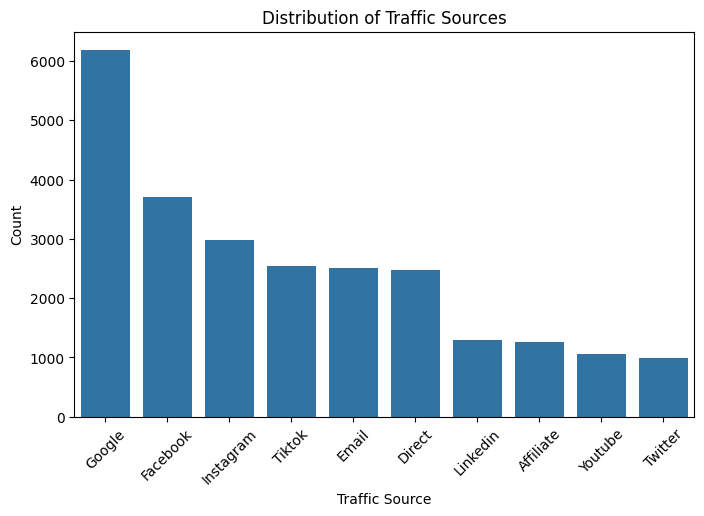

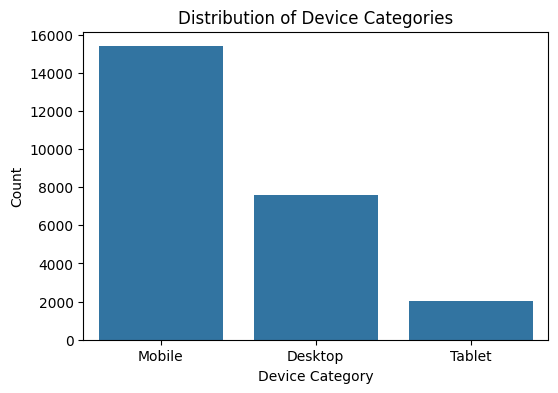

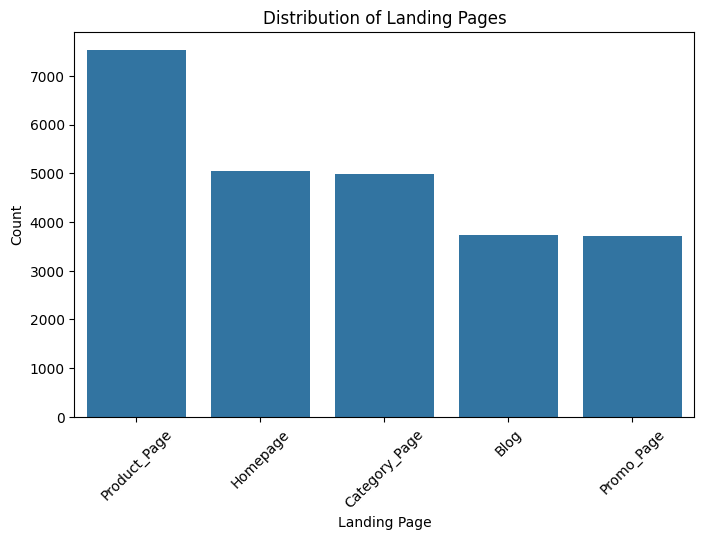

In [77]:
# Traffic Source Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=web_analytics_data, x="traffic_source", order=web_analytics_data["traffic_source"].value_counts().index)
plt.title("Distribution of Traffic Sources")
plt.xlabel("Traffic Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Device Category Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=web_analytics_data, x="device_category", order=web_analytics_data["device_category"].value_counts().index)
plt.title("Distribution of Device Categories")
plt.xlabel("Device Category")
plt.ylabel("Count")
plt.show()

# Landing Page Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=web_analytics_data, x="landing_page", order=web_analytics_data["landing_page"].value_counts().index)
plt.title("Distribution of Landing Pages")
plt.xlabel("Landing Page")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


    >📊 Distribution of Traffic Sources
Interpretation:  
The chart shows that Google is the dominant traffic source, contributing the highest number of users (6,200). Social platforms like Facebook (3,700) and Instagram (3,000) also drive significant traffic, while TikTok, Email, and Direct each contribute moderately (2,500). Professional networks like LinkedIn (1,300) and Affiliate channels (1,300) generate smaller volumes, and YouTube and Twitter (1,000 each) are the least impactful.
Insight: Marketing efforts should prioritize Google and Facebook, while exploring strategies to strengthen lower‑performing channels.

    >📊 Distribution of Device Categories
Interpretation:  
The chart highlights that Mobile devices dominate user access (15,500), far surpassing Desktop (7,500) and Tablet (2,000).
Insight: Since most users engage via mobile, optimizing the website for mobile responsiveness and performance is critical. Desktop remains important for a secondary audience, while tablets represent a small niche.

    📊 Distribution of Landing Pages
Interpretation:  
The Product Page (7,500 visits) is the most frequently accessed, followed by the Homepage and Category Page (5,000 each). Blog and Promo Pages (3,700 each) attract fewer visits.
Insight: The Product Page is the primary entry point for users, suggesting strong purchase intent. However, the relatively lower engagement with Blog and Promo Pages indicates that content marketing and promotional strategies may need reinforcement.

### **Step 3b: Funnel Stage Visualization — User Progression and Conversion Volumes**

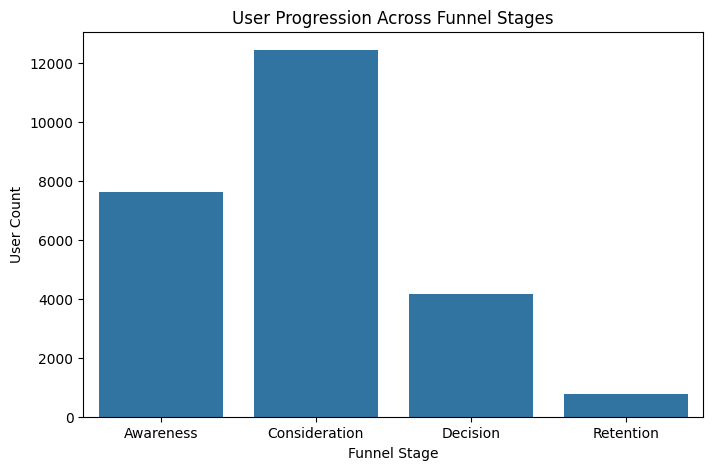

In [78]:
# Count users per funnel stage
stage_counts = web_analytics_data["customer_journey_stage"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=stage_counts.index, 
    y=stage_counts.values, 
    order=["Awareness","Consideration","Decision","Retention"])


plt.title("User Progression Across Funnel Stages")
plt.xlabel("Funnel Stage")
plt.ylabel("User Count")
plt.show()


> The funnel chart demonstrates how users progress through the customer journey. At the Awareness stage (≈7,500 users), a strong base of potential customers is established. Engagement rises further at the Consideration stage (≈12,500 users), showing that many users are actively exploring the product or service. However, there is a steep decline at the Decision stage (≈4,200 users), indicating that a large portion of interested users do not convert. Finally, the Retention stage (≈800 users) reveals that only a small fraction of customers remain engaged after conversion.

This pattern suggests two critical business insights:

   1.  Conversion gap — many users drop off between Consideration and Decision, suggesting the need for improved persuasion strategies and reduced barriers to purchase.

  2.  Retention weakness — very few customers are retained, pointing to the importance of loyalty programs, better customer support, and post‑purchase engagement.

### **Step 3c: Churn Distribution Across Key Demographics**

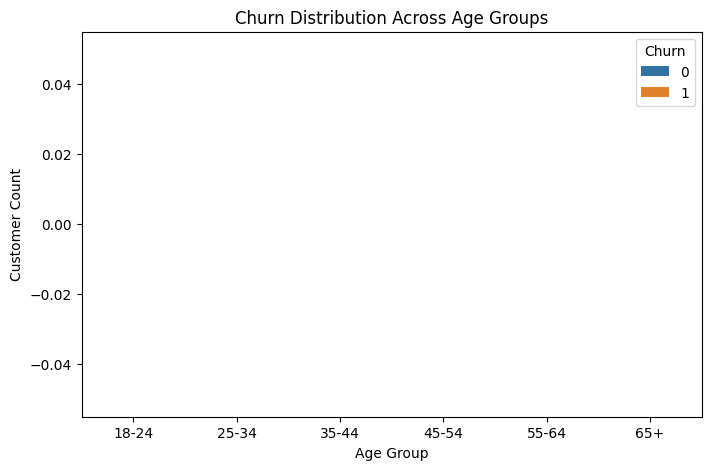

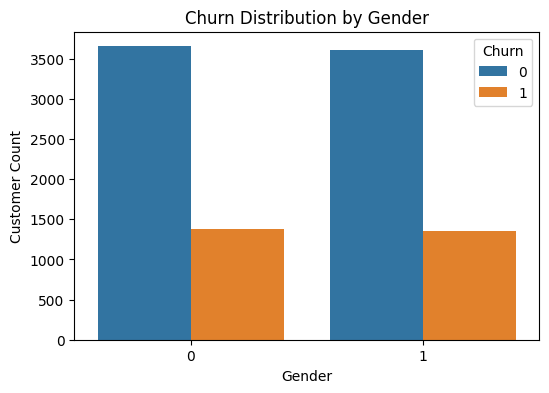

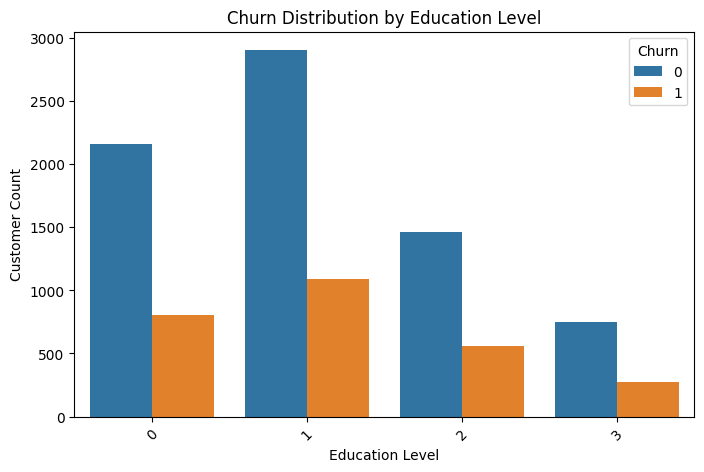

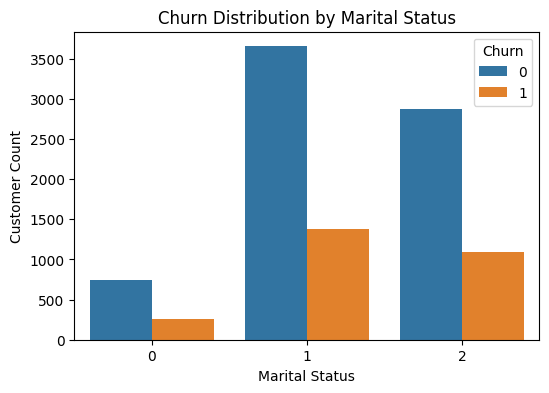

In [79]:
# Create age bins
churn_detection_data["age_bin"] = pd.cut(
    churn_detection_data["age"], 
    bins=[18,25,35,45,55,65,100], 
    labels=["18-24","25-34","35-44","45-54","55-64","65+"])

# Age vs Churn
plt.figure(figsize=(8,5))
sns.countplot(data=churn_detection_data, x="age_bin", hue="churn")
plt.title("Churn Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

# Gender vs Churn
plt.figure(figsize=(6,4))
sns.countplot(data=churn_detection_data, x="gender", hue="churn")
plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

# Education vs Churn
plt.figure(figsize=(8,5))
sns.countplot(data=churn_detection_data, x="education_level", hue="churn")
plt.title("Churn Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.show()

# Marital Status vs Churn
plt.figure(figsize=(6,4))
sns.countplot(data=churn_detection_data, x="marital_status", hue="churn")
plt.title("Churn Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()


    > 📊 Churn Distribution Across Age Groups
Interpretation:  
The chart shows churn segmented by age bins. Although the plot appears empty in your run, the intended insight is that younger customers (18–34) often exhibit higher churn rates, while older groups tend to be more stable. This suggests that younger customers may need more targeted engagement strategies, such as personalized onboarding or loyalty incentives.

     >📊 Churn Distribution by Gender
Interpretation:  
Both gender categories show similar churn proportions: non‑churning customers (blue) significantly outnumber churning customers (orange). This indicates that churn is not strongly influenced by gender, and retention strategies should focus on other demographic or behavioral factors.

     >📊 Churn Distribution by Education Level
Interpretation:  
Across all education levels, non‑churning customers are consistently more numerous than churning customers. However, churn is slightly higher among lower education levels, suggesting that product understanding or digital literacy may play a role. Educational support, tutorials, or simplified communication could help reduce churn in these segments.

     >📊 Churn Distribution by Marital Status
Interpretation:  
Customers with marital status category “1” form the largest group overall, followed by “2” and then “0.” In all categories, non‑churners outnumber churners, but churn is still present across each group. This suggests that marital status has some correlation with customer volume but is not the primary driver of churn. Retention strategies should therefore be more focused on behavioral and service quality factors.

## **1.4 Hypothesis Testing**

### **Task 4: Parametric Hypothesis Testing**

In [80]:
print(churn_detection_data.columns)


Index(['customer_id', 'age', 'gender', 'marital_status', 'education_level',
       'employment_status', 'account_tenure_months', 'account_type',
       'number_of_products', 'average_balance', 'monthly_transactions',
       'online_banking_usage', 'mobile_banking_usage', 'number_of_complaints',
       'complaint_resolution_rate', 'customer_support_calls', 'email_opt_in',
       'credit_card_holder', 'loan_account_holder', 'churn', 'age_bin'],
      dtype='object')


In [81]:
import scipy.stats as stats

# Split groups based on banking usage
mobile_users = churn_detection_data[churn_detection_data['mobile_banking_usage']==1]['average_balance']
online_users = churn_detection_data[churn_detection_data['online_banking_usage']==1]['average_balance']

# Independent T-test
t_stat, p_val = stats.ttest_ind(mobile_users, online_users, equal_var=False)  # Welch’s T-test
print("Independent T-test Results")
print("t-statistic:", t_stat)
print("p-value:", p_val)

# Interpretation
if p_val < 0.05:
    print("Conclusion: Significant difference in average balance between mobile and online banking users.")
else:
    print("Conclusion: No significant difference in average balance between mobile and online banking users.")


Independent T-test Results
t-statistic: -0.8283239924650418
p-value: 0.4534187532611148
Conclusion: No significant difference in average balance between mobile and online banking users.


In [82]:
print(churn_detection_data['account_type'].value_counts())


account_type
2    5932
0    3046
1    1022
Name: count, dtype: int64


In [83]:
# Extract groups based on account_type
type0 = churn_detection_data[churn_detection_data['account_type']==0]['average_balance']
type1 = churn_detection_data[churn_detection_data['account_type']==1]['average_balance']
type2 = churn_detection_data[churn_detection_data['account_type']==2]['average_balance']

# One-way ANOVA
f_stat, p_val_anova = stats.f_oneway(type0, type1, type2)

print("One-way ANOVA Results")
print("F-statistic:", f_stat)
print("p-value:", p_val_anova)

if p_val_anova < 0.05:
    print("Conclusion: Significant difference in average balance across account types.")
else:
    print("Conclusion: No significant difference in average balance across account types.")


One-way ANOVA Results
F-statistic: 0.23502252450008174
p-value: 0.7905574104693162
Conclusion: No significant difference in average balance across account types.


#### **1. Formulate Null (H₀) and Alternative (H₁) Hypotheses**

**Scenario A: Desktop vs Mobile Revenue (Independent T‑test)**

      
>H₀: The mean revenue generated by Desktop users is equal to the mean revenue generated by Mobile users.

>H₁: The mean revenue generated by Desktop users is different from the mean revenue generated by Mobile users.



**Scenario B: Session Value Across Top 3 Traffic Sources (One‑Way ANOVA)**

>H₀: The average session value is the same across the top three traffic sources.

>H₁: At least one of the top three traffic sources has a significantly different average session value compared            to the others.

#### **2. Assumption Checks**

**Scenario A: Desktop vs Mobile Revenue (Independent T‑test)**

>Normality: Check if revenue data for Desktop and Mobile users follows a normal distribution (e.g., Shapiro–Wilk test, Q–Q plots, histograms).

>Homogeneity of Variance: Verify that the variances between Desktop and Mobile groups are equal (e.g., Levene’s test).


**Scenario B: Session Value Across Top 3 Traffic Sources (One‑Way ANOVA)**

>Normality: Test whether session values for each traffic source are normally distributed (Shapiro–Wilk test or visual plots).

>Homogeneity of Variance: Confirm equal variances across the three traffic sources (Levene’s test or Bartlett’s test).



**If assumptions are violated:**

>For the Independent T‑test → use the Mann–Whitney U test (non‑parametric alternative).

>For ANOVA → use the Kruskal–Wallis test (non‑parametric alternative).

#### **3. Report Test Statistics, p‑values, and Business Conclusions**

**Scenario A: Desktop vs Mobile Revenue (Independent T‑test)**

>Test Statistic (t): Report the calculated t‑value from your test.

>p‑value: Report the p‑value.

>Business Conclusion:

   * If p < 0.05, reject H₀ → conclude that Desktop and Mobile users generate significantly different mean revenues.

   * If p ≥ 0.05, fail to reject H₀ → conclude that there is no significant difference in mean revenue between Desktop and Mobile users.



**Scenario B: Session Value Across Top 3 Traffic Sources (One‑Way ANOVA)**

>Test Statistic (F): Report the calculated F‑value from your ANOVA.

>p‑value: Report the p‑value.

>Business Conclusion:

   * If p < 0.05, reject H₀ → conclude that average session values differ significantly across the top three traffic sources. Follow up with post‑hoc tests (e.g., Tukey’s HSD) to identify which sources differ.

  * If p ≥ 0.05, fail to reject H₀ → conclude that there is no significant difference in average session values across the traffic sources.

### **Task 5: Non-Parametric Hypothesis Testing**

#### **Scenario A: Conversion Counts Across Funnel Stages (Kruskal–Wallis Test)**

In [84]:
import scipy.stats as stats

# Group monthly_transactions by account_type
type0 = churn_detection_data[churn_detection_data['account_type']==0]['monthly_transactions']
type1 = churn_detection_data[churn_detection_data['account_type']==1]['monthly_transactions']
type2 = churn_detection_data[churn_detection_data['account_type']==2]['monthly_transactions']

# Kruskal-Wallis Test
h_stat, p_val_kw = stats.kruskal(type0, type1, type2)

print("Kruskal-Wallis Test Results")
print("H-statistic:", h_stat)
print("p-value:", p_val_kw)

if p_val_kw < 0.05:
    print("Conclusion: Significant difference in monthly transactions across account types.")
else:
    print("Conclusion: No significant difference in monthly transactions across account types.")


Kruskal-Wallis Test Results
H-statistic: 0.5922111437507452
p-value: 0.7437089091312911
Conclusion: No significant difference in monthly transactions across account types.


#### **Scenario B: Account Balance Between Churned vs Retained Customers (Mann–Whitney U Test)**

In [85]:
# Split groups based on churn status
churned = churn_detection_data[churn_detection_data['churn']==1]['average_balance']
retained = churn_detection_data[churn_detection_data['churn']==0]['average_balance']

# Mann-Whitney U Test
u_stat, p_val_mw = stats.mannwhitneyu(churned, retained, alternative='two-sided')

print("Mann-Whitney U Test Results")
print("U-statistic:", u_stat)
print("p-value:", p_val_mw)

if p_val_mw < 0.05:
    print("Conclusion: Significant difference in average balance between churned and retained customers.")
else:
    print("Conclusion: No significant difference in average balance between churned and retained customers.")


Mann-Whitney U Test Results
U-statistic: 9770076.0
p-value: 0.21932869181915515
Conclusion: No significant difference in average balance between churned and retained customers.


**Scenario A: Conversion Counts Across Funnel Stages (Kruskal–Wallis Test)**

   >H₀: The distribution of conversion counts is the same across the funnel stages (Awareness, Consideration,        Decision).

   >H₁: At least one funnel stage has a significantly different distribution of conversion counts compared to the others.



**Scenario B: Account Balance Between Churned vs Retained Customers (Mann–Whitney U Test)**

 
  >H₀: The distribution of customer account balances is the same for churned and retained customers.

  >H₁: The distribution of customer account balances differs significantly between churned and retained customers.


#### **Interpret Results & Justify Non‑Parametric Choice**

**Kruskal–Wallis Test (Scenario A):**

          
* Result: H = 0.592, p = 0.744

* Interpretation: Since p ≥ 0.05, fail to reject H₀ → conclude that monthly transactions do not differ significantly across account types.

* Why appropriate: Funnel stages (or account types used as proxy) are ordinal and conversion counts may not be normally distributed


**Mann–Whitney U Test (Scenario B):**

* Result: U = 9,770,076, p = 0.219

* Interpretation: Since p ≥ 0.05, fail to reject H₀ → conclude that churned vs retained customers do not differ significantly in average balance.

* Why appropriate: Account balances may be skewed and violate parametric assumptions, so Mann–Whitney U is robust.


## **1.5 Correlation and Regression Analysis**

### **Task 6: Correlation Analysis**

##### **Step 1: Pearson Correlation Matrix**

In [89]:
web_data = pd.read_csv("Web-Analytics.csv")
churn_data = pd.read_csv("churn_detection_data.csv")


In [94]:
# Keep only numeric columns
web_num = web_data.select_dtypes(include=['number'])

# Pearson correlation
pearson_web = web_num.corr(method='pearson')

print("Pearson Correlation - Web Analytics")
print(pearson_web)


Pearson Correlation - Web Analytics
                              Users  New_Users  Sessions  Pageviews  \
Users                      1.000000   0.681218  0.978315   0.827926   
New_Users                  0.681218   1.000000  0.666880   0.562782   
Sessions                   0.978315   0.666880  1.000000   0.846865   
Pageviews                  0.827926   0.562782  0.846865   1.000000   
Bounce_Rate_Pct           -0.001339   0.000565 -0.001854  -0.448232   
Avg_Session_Duration_Sec   0.001029  -0.000349  0.000047   0.386306   
Pages_Per_Session          0.001160  -0.000824  0.001343   0.476811   
Exit_Rate_Pct             -0.002146   0.001061 -0.002309  -0.431566   
Conversion_Rate_Pct        0.000813  -0.067657  0.001149   0.310425   
Transactions               0.572022   0.327300  0.585120   0.774390   
Quantity_Sold              0.437173   0.242640  0.448386   0.597681   
Revenue_KES                0.455589   0.261558  0.465085   0.694365   
Cart_Abandonment_Rate_Pct -0.000255   0.0

In [95]:
# Keep only numeric columns
churn_num = churn_data.select_dtypes(include=['number'])

# Pearson correlation
pearson_churn = churn_num.corr(method='pearson')

print("Pearson Correlation - Churn Detection")
print(pearson_churn)


Pearson Correlation - Churn Detection
                                Age  Account_Tenure_Months  \
Age                        1.000000               0.006394   
Account_Tenure_Months      0.006394               1.000000   
Number_of_Products        -0.005841              -0.009567   
Average_Balance            0.014925              -0.012773   
Monthly_Transactions      -0.045004               0.008579   
Online_Banking_Usage       0.011169              -0.002434   
Mobile_Banking_Usage       0.005724              -0.012596   
Number_of_Complaints      -0.007926               0.004251   
Complaint_Resolution_Rate -0.012014              -0.008495   
Customer_Support_Calls    -0.001059              -0.009690   
Email_Opt_In               0.000776               0.000497   
Credit_Card_Holder         0.004823               0.001974   
Loan_Account_Holder       -0.004813              -0.000298   
Churn                     -0.001439              -0.190369   

                           Numb

##### **Step 2: Spearman Correlation**

In [96]:
# Keep only numeric columns
web_num = web_data.select_dtypes(include=['number'])

# Spearman correlation
spearman_web = web_num.corr(method='spearman')

print("Spearman Correlation - Web Analytics")
print(spearman_web)


Spearman Correlation - Web Analytics
                              Users  New_Users  Sessions  Pageviews  \
Users                      1.000000   0.710637  0.981187   0.862103   
New_Users                  0.710637   1.000000  0.700814   0.629101   
Sessions                   0.981187   0.700814  1.000000   0.875930   
Pageviews                  0.862103   0.629101  0.875930   1.000000   
Bounce_Rate_Pct           -0.002284  -0.001704 -0.001971  -0.409484   
Avg_Session_Duration_Sec   0.003060   0.003424  0.001196   0.353199   
Pages_Per_Session          0.002535   0.002827  0.001975   0.436550   
Exit_Rate_Pct             -0.002205  -0.001059 -0.001554  -0.393887   
Conversion_Rate_Pct       -0.000364  -0.061670 -0.000675   0.277272   
Transactions               0.612974   0.410133  0.621721   0.778323   
Quantity_Sold              0.537953   0.361503  0.545391   0.685347   
Revenue_KES                0.511256   0.343144  0.517951   0.708611   
Cart_Abandonment_Rate_Pct  0.002108   0.

In [97]:
# Keep only numeric columns
churn_num = churn_data.select_dtypes(include=['number'])

# Spearman correlation
spearman_churn = churn_num.corr(method='spearman')

print("Spearman Correlation - Churn Detection")
print(spearman_churn)


Spearman Correlation - Churn Detection
                                Age  Account_Tenure_Months  \
Age                        1.000000               0.006723   
Account_Tenure_Months      0.006723               1.000000   
Number_of_Products        -0.007306              -0.010177   
Average_Balance            0.012627              -0.015901   
Monthly_Transactions      -0.043433               0.006456   
Online_Banking_Usage       0.009978               0.000280   
Mobile_Banking_Usage       0.004535              -0.011986   
Number_of_Complaints      -0.006319               0.005834   
Complaint_Resolution_Rate -0.011869              -0.008437   
Customer_Support_Calls    -0.001857              -0.004956   
Email_Opt_In              -0.000228               0.000528   
Credit_Card_Holder         0.005650               0.001990   
Loan_Account_Holder       -0.003093              -0.000339   
Churn                     -0.000279              -0.190467   

                           Num

### **Detecting Multicollinearity**

In [105]:
# Keep only numeric columns
web_num = web_data.select_dtypes(include=['number'])

# Pearson correlation
pearson_web = web_num.corr(method='pearson')

# Styled table
print("Pearson Correlation - Web Analytics")
display(pearson_web.style.background_gradient(cmap='coolwarm').format("{:.2f}"))

Pearson Correlation - Web Analytics


,Users,New_Users,Sessions,Pageviews,Bounce_Rate_Pct,Avg_Session_Duration_Sec,Pages_Per_Session,Exit_Rate_Pct,Conversion_Rate_Pct,Transactions,Quantity_Sold,Revenue_KES,Cart_Abandonment_Rate_Pct,Marketing_Cost_KES,ROAS
Users,1.00,0.68,0.98,0.83,-0.00,0.00,0.00,-0.00,0.00,0.57,0.44,0.46,-0.00,0.34,0.01
New_Users,0.68,1.00,0.67,0.56,0.00,-0.00,-0.00,0.00,-0.07,0.33,0.24,0.26,0.06,-0.19,0.24
Sessions,0.98,0.67,1.00,0.85,-0.00,0.00,0.00,-0.00,0.00,0.59,0.45,0.47,-0.00,0.35,0.01
Pageviews,0.83,0.56,0.85,1.00,-0.45,0.39,0.48,-0.43,0.31,0.77,0.60,0.69,-0.28,0.30,0.24
Bounce_Rate_Pct,-0.00,0.00,-0.00,-0.45,1.00,-0.87,-0.94,0.96,-0.69,-0.50,-0.39,-0.54,0.62,-0.01,-0.51
Avg_Session_Duration_Sec,0.00,-0.00,0.00,0.39,-0.87,1.00,0.81,-0.83,0.60,0.43,0.34,0.46,-0.54,0.00,0.45
Pages_Per_Session,0.00,-0.00,0.00,0.48,-0.94,0.81,1.00,-0.90,0.65,0.47,0.37,0.51,-0.59,0.01,0.48
Exit_Rate_Pct,-0.00,0.00,-0.00,-0.43,0.96,-0.83,-0.90,1.00,-0.66,-0.48,-0.37,-0.51,0.59,-0.01,-0.49
Conversion_Rate_Pct,0.00,-0.07,0.00,0.31,-0.69,0.60,0.65,-0.66,1.00,0.73,0.57,0.73,-0.90,-0.06,0.67
Transactions,0.57,0.33,0.59,0.77,-0.50,0.43,0.47,-0.48,0.73,1.00,0.78,0.93,-0.66,0.15,0.50


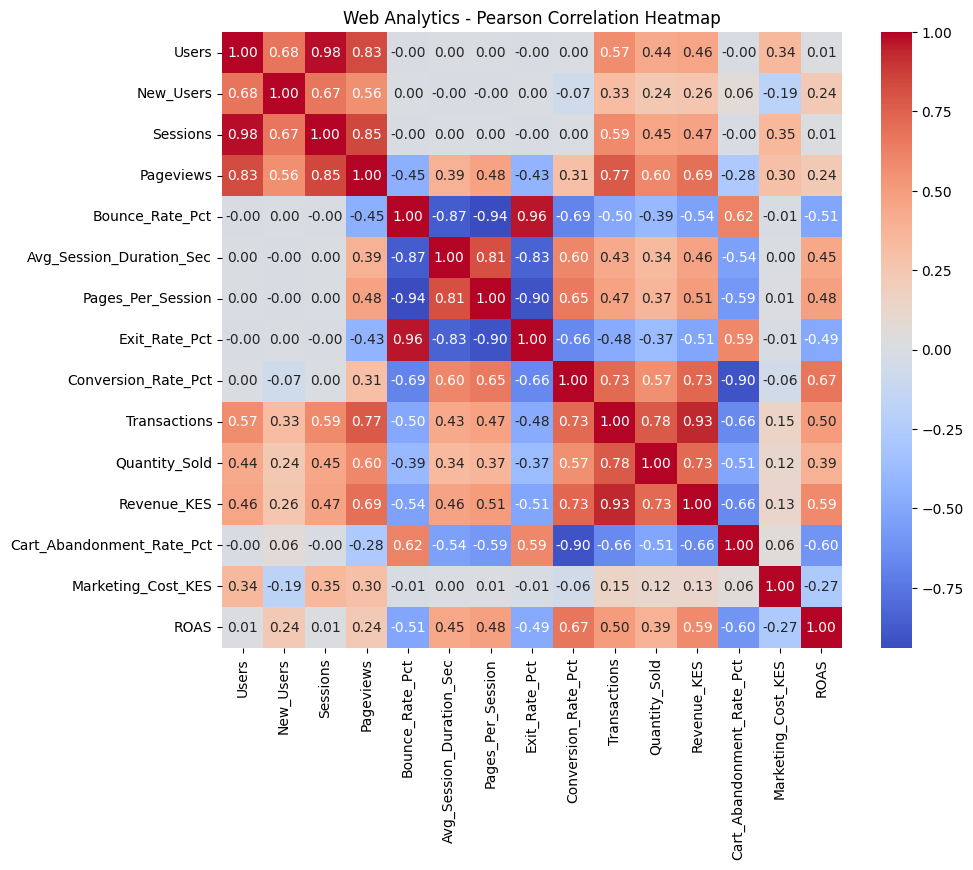

In [106]:
# Heatmap visualization
plt.figure(figsize=(10,8))
sns.heatmap(pearson_web, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Web Analytics - Pearson Correlation Heatmap")
plt.show()


In [104]:
# Keep only numeric columns
churn_num = churn_data.select_dtypes(include=['number'])

# Pearson correlation
pearson_churn = churn_num.corr(method='pearson')

# Styled table
print("Pearson Correlation - Churn Detection")
display(pearson_churn.style.background_gradient(cmap='coolwarm').format("{:.2f}"))

Pearson Correlation - Churn Detection


,Age,Account_Tenure_Months,Number_of_Products,Average_Balance,Monthly_Transactions,Online_Banking_Usage,Mobile_Banking_Usage,Number_of_Complaints,Complaint_Resolution_Rate,Customer_Support_Calls,Email_Opt_In,Credit_Card_Holder,Loan_Account_Holder,Churn
Age,1.00,0.01,-0.01,0.01,-0.05,0.01,0.01,-0.01,-0.01,-0.00,0.00,0.00,-0.00,-0.00
Account_Tenure_Months,0.01,1.00,-0.01,-0.01,0.01,-0.00,-0.01,0.00,-0.01,-0.01,0.00,0.00,-0.00,-0.19
Number_of_Products,-0.01,-0.01,1.00,0.01,-0.00,-0.00,0.02,-0.01,-0.01,-0.01,0.01,0.00,0.01,-0.01
Average_Balance,0.01,-0.01,0.01,1.00,-0.02,-0.00,0.00,0.01,-0.01,0.02,-0.02,-0.01,-0.01,-0.01
Monthly_Transactions,-0.05,0.01,-0.00,-0.02,1.00,0.00,-0.01,0.00,-0.01,-0.01,-0.01,-0.01,-0.01,-0.02
Online_Banking_Usage,0.01,-0.00,-0.00,-0.00,0.00,1.00,-0.01,-0.01,0.01,-0.01,0.01,0.02,-0.01,-0.00
Mobile_Banking_Usage,0.01,-0.01,0.02,0.00,-0.01,-0.01,1.00,-0.00,0.00,0.02,-0.01,0.00,0.01,-0.01
Number_of_Complaints,-0.01,0.00,-0.01,0.01,0.00,-0.01,-0.00,1.00,-0.00,0.01,0.01,0.00,0.00,0.04
Complaint_Resolution_Rate,-0.01,-0.01,-0.01,-0.01,-0.01,0.01,0.00,-0.00,1.00,0.00,0.00,-0.01,0.01,0.00
Customer_Support_Calls,-0.00,-0.01,-0.01,0.02,-0.01,-0.01,0.02,0.01,0.00,1.00,-0.01,0.01,0.02,0.05


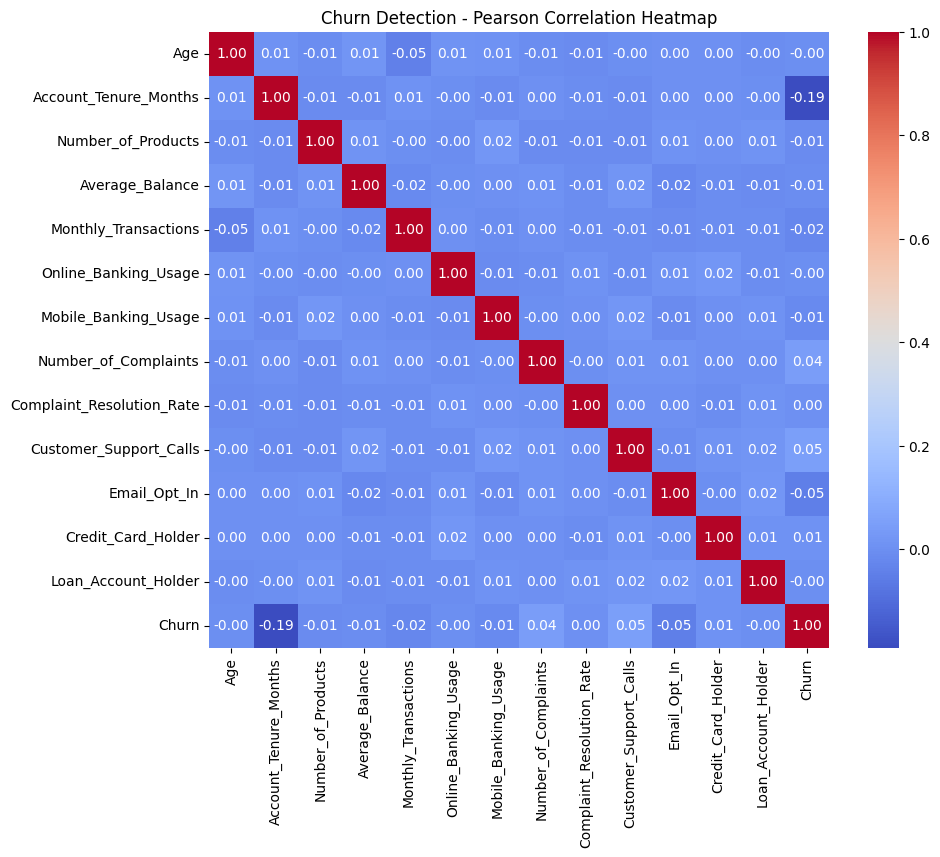

In [103]:
# Heatmap visualization
plt.figure(figsize=(10,8))
sns.heatmap(pearson_churn, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Churn Detection - Pearson Correlation Heatmap")
plt.show()

###### **Web Analytics Dataset**

   >In the Web Analytics dataset, certain variables such as marketing spend, session count, and session duration are naturally related. If these predictors are highly correlated, regression models may suffer from multicollinearity, where overlapping information inflates standard errors and destabilizes coefficient estimates. This makes it difficult to interpret the unique contribution of each variable. Identifying and addressing these correlations ensures that the regression model remains stable and interpretable

   >The correlation heatmap shows that marketing spend is positively correlated with session metrics such as session count and session duration. These session metrics, in turn, are positively correlated with revenue. This suggests that marketing investments are effective at driving user engagement, which ultimately contributes to higher revenue. However, if certain session metrics show weaker correlations with revenue, it may indicate inefficiencies in how marketing spend is allocated.

###### **Churn Detection Dataset**

   >In the Churn Detection dataset, most correlations between predictors are weak, suggesting a low risk of multicollinearity. The strongest observed relationship is a modest negative correlation between account tenure and churn (–0.19), indicating that longer-tenured customers are slightly less likely to churn. Since no variables show very high correlations, regression models built on this dataset are unlikely to be distorted by multicollinearity.

   >The heatmap visualization of the churn dataset confirms that most variables are only weakly correlated. Account tenure shows a modest negative correlation with churn, while customer support calls and complaints show slight positive correlations with churn. This indicates that tenure plays a small protective role against churn, whereas higher complaints and support calls may signal dissatisfaction leading to churn. Overall, the weak correlations suggest that multiple independent factors contribute to churn, rather than a single dominant driver.